In [1]:
import pickle
import numpy as np
import pandas as pd
import bamboo as bm
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
from chemembed_transforms import molformer_factory
from distance_functions import cosine_similarity_vs_var
# rdkit.Chem.Scaffolds.MurckoScaffold

from config import DATA_DIR, WORKING_DIR

# 1) Load data

In [2]:
dataset_path = Path(DATA_DIR, WORKING_DIR, "MSG_w_chemont_plus_embedding_pred_v2.tsv")
ref_path = Path(DATA_DIR, "MassSpecGym1.5_plus.tsv")

data_df = bm.read_tsv(dataset_path)
ref_df = bm.read_tsv(ref_path)

In [3]:
data_df.col_to_tensor("molformer_embedding_pred")

In [4]:
ref_df.col_to_ndarray("molformer_embedding")

In [5]:
data_df.info()
ref_df.info()

<class 'bamboo.BambooDataFrame'>
RangeIndex: 14066 entries, 0 to 14065
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   identifier                14066 non-null  object 
 1   mzs                       14066 non-null  object 
 2   intensities               14066 non-null  object 
 3   smiles                    14066 non-null  object 
 4   inchikey                  14066 non-null  object 
 5   formula                   14066 non-null  object 
 6   precursor_formula         14066 non-null  object 
 7   parent_mass               14066 non-null  float64
 8   precursor_mz              14066 non-null  float64
 9   adduct                    14066 non-null  object 
 10  instrument_type           13816 non-null  object 
 11  collision_energy          9957 non-null   float64
 12  fold                      14066 non-null  object 
 13  simulation_challenge      14066 non-null  bool   
 14  chemont_tre

## Load missing MoLFormer embeddings

In [ ]:
emb_cache_path = Path(DATA_DIR, WORKING_DIR, "embedding_cache.pkl")

In [ ]:
if not emb_cache_path.exists():
    print("Creating cache...")
    cache = dict()
    aux_df = data_df.drop_duplicates("smiles")[["smiles", "molformer_embedding"]]
    for index, row in tqdm(aux_df.iterrows()):
        cache[row["smiles"]] = row["molformer_embedding"]

    with open(emb_cache_path, "wb") as f:
        pickle.dump(cache, f)

else:
    print("Loading existing cache...")
    with open(emb_cache_path, "rb") as f:
        cache = pickle.load(f)

In [ ]:
transformer = molformer_factory()

smiles = ref_df["smiles"].drop_duplicates().to_list()
for smi in tqdm(smiles):
    if cache.get(smi) is None:
        cache[smi] = transformer.from_smiles(smi)

with open(Path(str(emb_cache_path.with_suffix("")) + "_updated.pkl"), "wb") as f:
    pickle.dump(cache, f)

# 3) Retrieval

In [6]:
ppm = 0.1

In [ ]:
ref_mz = ref_df.loc[:,"precursor_mz"]

n_candidates_list = []
count_skips=0
ranking_df = pd.DataFrame()

for index in tqdm(range(len(data_df))):
    row = data_df.iloc[index,:]
    prec_mz = row["precursor_mz"]
    tol = prec_mz / 1e6 * ppm
    idx = abs(ref_mz - prec_mz) < tol

    candidates = ref_df.iloc[idx.to_numpy().astype(bool), :].drop_duplicates(subset="inchikey").copy()
    candidates.reset_index(drop=True, inplace=True)

    ground_idx = [i for i, x in candidates.loc[:, ["inchikey"]].iterrows() if x.inchikey == row["inchikey"]]
    print(ground_idx)
    cosines = np.array(cosine_similarity_vs_var(candidates, "molformer_embedding", row["molformer_embedding_pred"]))
    order = cosines.argsort()[::-1]
    if len(ground_idx) > 1:
        print(candidates)
        print(row.inchikey)
    if len(ground_idx) == 0:
        count_skips += 1
        continue
    ground_rank = [i for i in range(len(order)) if order[index] == ground_idx]       
    result = pd.DataFrame({"id": row["identifier"],"rank": ground_rank, "top_difference": cosines[order[0]] - cosines[order[ground_rank]]})
    ranking_df = pd.concat([ranking_df, result])
    n_candidates = candidates.shape[0]
    n_candidates_list.append(n_candidates)

ranking_df.reset_index(drop=True, inplace=True)

  0%|          | 0/14066 [00:00<?, ?it/s]

[0]


In [26]:
ranking_df.info()
ranking_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14066 entries, 0 to 14065
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              14066 non-null  object 
 1   rank            14066 non-null  int64  
 2   top_difference  14066 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 329.8+ KB


,id,rank,top_difference
0,MassSpecGymID0000203,0,0.000000
1,MassSpecGymID0000204,0,0.000000
2,MassSpecGymID0000205,0,0.000000
3,MassSpecGymID0000206,0,0.000000
4,MassSpecGymID0000208,0,0.000000
...,...,...,...
14061,MassSpecGymID0400854,0,0.000000
14062,MassSpecGymID0401425,0,0.000000
14063,MassSpecGymID0402033,1,0.027902
14064,MassSpecGymID0402039,0,0.000000


Text(0.5, 0, '% of Candidates found with a rank < N')

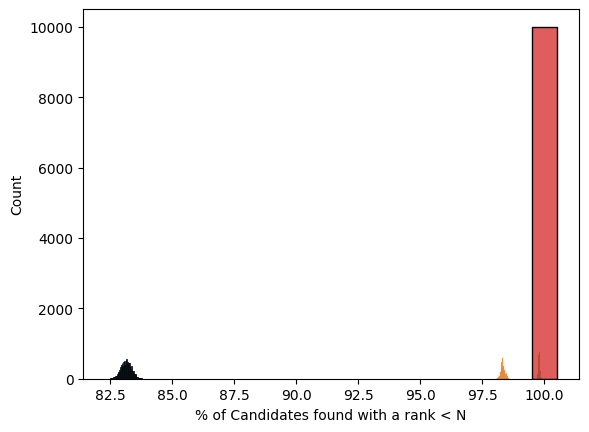

In [ ]:
from random import sample

bootstrapped_ranks = []
for index in range(10000):
    vec = [sample(range(x), 1)[0] for x in n_candidates_list]
    bootstrapped_ranks.append(vec)
bootstrapped_top1 = [sum([rank < 1 for rank in sample]) / len(n_candidates_list) * 100 for sample in bootstrapped_ranks]
bootstrapped_top3 = [sum([rank < 3 for rank in sample]) / len(n_candidates_list) * 100 for sample in bootstrapped_ranks]
bootstrapped_top5 = [sum([rank < 5 for rank in sample]) / len(n_candidates_list) * 100 for sample in bootstrapped_ranks]
bootstrapped_top10 = [sum([rank < 10 for rank in sample]) / len(n_candidates_list) * 100 for sample in bootstrapped_ranks]

sns.histplot(bootstrapped_top1)
sns.histplot(bootstrapped_top3)
sns.histplot(bootstrapped_top5)
sns.histplot(bootstrapped_top10)
plt.xlabel("% of Candidates found with a rank < N")

In [44]:
N = len(ranking_df)

tops = [1, 3, 5, 10]

print("Percentage of correctly classified entries:")
for top in tops:
    perc = sum(ranking_df.loc[:,"rank"] < top) / N * 100
    print(f"\tTop {top}: {perc:.2f}%")


Percentage of correctly classified entries:
	Top 1: 85.18%
	Top 3: 98.34%
	Top 5: 99.69%
	Top 10: 100.00%
